# Quantile model for shape metrics

In [ ]:
import sys
import os

import numpy as np
import torch
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load data and model

In [ ]:
X = pd.read_csv("../_temp/X.csv").drop(columns="Slurry")
y = pd.read_csv("../_temp/y.csv")
data = pd.concat([X, y], axis=1)

In [ ]:
from model.load import load_H_models

_, H_X_scaler, H_y_scaler, H_mean, _, H_model = load_H_models(device=device)

H_X_scaler.eval()
H_y_scaler.eval()
H_mean.eval()
H_model.eval();

In [ ]:
from model.load import load_phi_models

_, phi_X_scaler, phi_y_scaler, phi_mean, _, phi_model = load_phi_models(device=device)

phi_X_scaler.eval()
phi_y_scaler.eval()
phi_mean.eval()
phi_model.eval();

## Plot

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter

In [ ]:
groups = list(data.groupby(["Cos_theta"]))
Rgts = data["Gap_to_thickness_ratio"]
Rgt_pred = np.linspace(Rgts.min(), Rgts.max(), 100)
Cas = data["Capillary_number"]

ca_unique = np.sort(Cas.unique())
n_colors = len(ca_unique)
cmap = plt.get_cmap("viridis", n_colors)
norm = mcolors.BoundaryNorm(
    np.concatenate(
        [
            [ca_unique[0] * 0.9],
            (ca_unique[:-1] + ca_unique[1:]) / 2,
            [ca_unique[-1] * 1.1],
        ]
    ),
    ncolors=n_colors,
)

## Prior mean

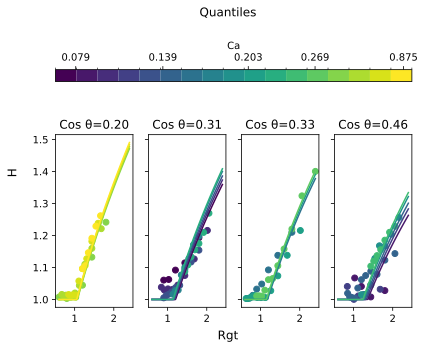

In [ ]:
fig, axes = plt.subplots(1, len(groups), sharex=True, sharey="row")
if len(groups) == 1:
    axes = [axes]

for ax, ((cos_theta,), df) in zip(axes, groups):

    for Ca, sub_df in df.groupby("Capillary_number", observed=True, as_index=False):
        color = cmap(norm(Ca))
        ax.scatter(sub_df["Gap_to_thickness_ratio"], sub_df["H"], color=color)

        X_pred = np.stack(
            [
                Rgt_pred,
                np.full_like(Rgt_pred, Ca),
                np.full_like(Rgt_pred, cos_theta),
            ],
            axis=-1,
        )
        with torch.no_grad():
            prior_mean = H_mean(
                torch.tensor(X_pred, dtype=torch.float32, device=device)
            )
        ax.plot(
            Rgt_pred,
            prior_mean.cpu().numpy(),
            color=color,
        )

    ax.set_title(f"Cos θ={cos_theta:.2f}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=axes, orientation="horizontal", location="top", pad=0.2, aspect=30
)
cbar.set_label("Ca")
quartile_vals = np.quantile(Cas.values, [0, 0.25, 0.5, 0.75, 1.0])
nearest_cas = [ca_unique[np.argmin(np.abs(ca_unique - q))] for q in quartile_vals]
cbar.set_ticks([round(ca, 3) for ca in nearest_cas])
cbar.ax.xaxis.set_major_formatter(ScalarFormatter())

fig.supxlabel("Rgt")
fig.supylabel("H")
fig.suptitle("Quantiles")

plt.show()

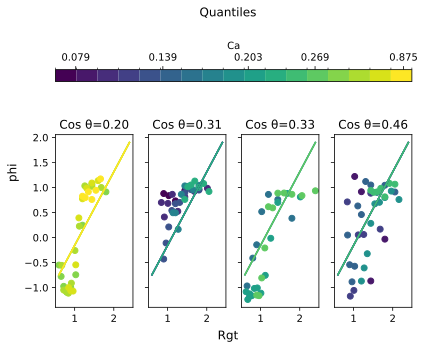

In [ ]:
fig, axes = plt.subplots(1, len(groups), sharex=True, sharey="row")
if len(groups) == 1:
    axes = [axes]

for ax, ((cos_theta,), df) in zip(axes, groups):

    for Ca, sub_df in df.groupby("Capillary_number", observed=True, as_index=False):
        color = cmap(norm(Ca))
        ax.scatter(sub_df["Gap_to_thickness_ratio"], sub_df["phi"], color=color)

        X_pred = np.stack(
            [
                Rgt_pred,
                np.full_like(Rgt_pred, Ca),
                np.full_like(Rgt_pred, cos_theta),
            ],
            axis=-1,
        )
        with torch.no_grad():
            prior_mean = phi_mean(
                torch.tensor(X_pred, dtype=torch.float32, device=device)
            )
        ax.plot(
            Rgt_pred,
            prior_mean.cpu().numpy(),
            color=color,
        )

    ax.set_title(f"Cos θ={cos_theta:.2f}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=axes, orientation="horizontal", location="top", pad=0.2, aspect=30
)
cbar.set_label("Ca")
quartile_vals = np.quantile(Cas.values, [0, 0.25, 0.5, 0.75, 1.0])
nearest_cas = [ca_unique[np.argmin(np.abs(ca_unique - q))] for q in quartile_vals]
cbar.set_ticks([round(ca, 3) for ca in nearest_cas])
cbar.ax.xaxis.set_major_formatter(ScalarFormatter())

fig.supxlabel("Rgt")
fig.supylabel("phi")
fig.suptitle("Quantiles")

plt.show()

## Quantiles

In [ ]:
CHUNK = 4096


def predict(X, X_scaler, y_scaler, mean, model):
    X_raw = torch.tensor(X, dtype=torch.float32, device=device)

    quantiles = []
    with torch.no_grad():
        for i in range(0, X_raw.shape[0], CHUNK):
            X_pred = X_raw[i : i + CHUNK]
            X_scaled = X_scaler(X_pred)
            scaled_res_quantiles = model.mean_quantiles_delta(X_scaled)
            pred_res = y_scaler.inverse_transform(scaled_res_quantiles)
            pred_mean = mean(X_pred).reshape(-1, 1)
            pred_quantiles = pred_res + pred_mean
            quantiles.append(pred_quantiles.cpu().numpy())
    return np.concatenate(quantiles, axis=0)

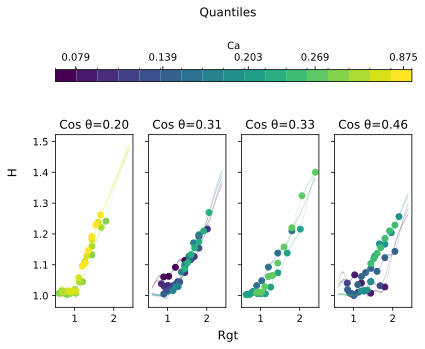

In [ ]:
fig, axes = plt.subplots(1, len(groups), sharex=True, sharey="row")
if len(groups) == 1:
    axes = [axes]

for ax, ((cos_theta,), df) in zip(axes, groups):

    for Ca, sub_df in df.groupby("Capillary_number", observed=True, as_index=False):
        color = cmap(norm(Ca))
        ax.scatter(sub_df["Gap_to_thickness_ratio"], sub_df["H"], color=color)

        X_pred = np.stack(
            [
                Rgt_pred,
                np.full_like(Rgt_pred, Ca),
                np.full_like(Rgt_pred, cos_theta),
            ],
            axis=-1,
        )
        with torch.no_grad():
            quantiles = predict(X_pred, H_X_scaler, H_y_scaler, H_mean, H_model)
        q_low, q_high = quantiles.T[[0, -1], ...]
        ax.fill_between(
            Rgt_pred,
            q_low,
            q_high,
            facecolor=color,
            edgecolor="none",
            alpha=0.3,
        )

    ax.set_title(f"Cos θ={cos_theta:.2f}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=axes, orientation="horizontal", location="top", pad=0.2, aspect=30
)
cbar.set_label("Ca")
quartile_vals = np.quantile(Cas.values, [0, 0.25, 0.5, 0.75, 1.0])
nearest_cas = [ca_unique[np.argmin(np.abs(ca_unique - q))] for q in quartile_vals]
cbar.set_ticks([round(ca, 3) for ca in nearest_cas])
cbar.ax.xaxis.set_major_formatter(ScalarFormatter())

fig.supxlabel("Rgt")
fig.supylabel("H")
fig.suptitle("Quantiles")

plt.show()

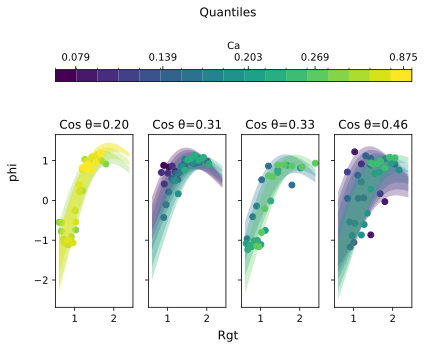

In [ ]:
fig, axes = plt.subplots(1, len(groups), sharex=True, sharey="row")
if len(groups) == 1:
    axes = [axes]

for ax, ((cos_theta,), df) in zip(axes, groups):

    for Ca, sub_df in df.groupby("Capillary_number", observed=True, as_index=False):
        color = cmap(norm(Ca))
        ax.scatter(sub_df["Gap_to_thickness_ratio"], sub_df["phi"], color=color)

        X_pred = np.stack(
            [
                Rgt_pred,
                np.full_like(Rgt_pred, Ca),
                np.full_like(Rgt_pred, cos_theta),
            ],
            axis=-1,
        )
        with torch.no_grad():
            quantiles = predict(X_pred, phi_X_scaler, phi_y_scaler, phi_mean, phi_model)
        q_low, q_high = quantiles.T[[0, -1], ...]
        ax.fill_between(
            Rgt_pred,
            q_low,
            q_high,
            facecolor=color,
            edgecolor="none",
            alpha=0.3,
        )

    ax.set_title(f"Cos θ={cos_theta:.2f}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=axes, orientation="horizontal", location="top", pad=0.2, aspect=30
)
cbar.set_label("Ca")
quartile_vals = np.quantile(Cas.values, [0, 0.25, 0.5, 0.75, 1.0])
nearest_cas = [ca_unique[np.argmin(np.abs(ca_unique - q))] for q in quartile_vals]
cbar.set_ticks([round(ca, 3) for ca in nearest_cas])
cbar.ax.xaxis.set_major_formatter(ScalarFormatter())

fig.supxlabel("Rgt")
fig.supylabel("phi")
fig.suptitle("Quantiles")

plt.show()